In [16]:
using MLJ
using MLJFlux
using MLJScikitLearnInterface
using NearestNeighborModels
using Random
using LIBSVM
using Pkg
using MLJModelInterface
using MLJBase
using CategoricalArrays
using Statistics
using DataFrames
using CSV
using Tables
import MLJBase: fit!, transform, machine
using Plots
using PlotlyJS
using StatsBase


In [2]:
include("P2.jl")
include("PEARSON.jl")
include("SPEARMAN.jl")
include("ANOVA.jl")
include("KENDALL_TAU.jl")
include("RFE.jl")
include("MUTUALINFORMATION.jl")
include("LLE.jl")
include("TSNE.jl")
include("ISOMAP.jl")

In [3]:
PCA = @load PCA pkg=MultivariateStats verbosity = 0
ICA = @load ICA pkg=MultivariateStats verbosity = 0
LDA = @load LDA pkg=MultivariateStats verbosity = 0

KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels verbosity = 0
SVC = @load ProbabilisticSVC pkg=LIBSVM verbosity = 0
NeuralNetworkClassifier = @load NeuralNetworkClassifier pkg=MLJFlux verbosity = 0

RandomForestClassifier = @load RandomForestClassifier pkg=DecisionTree verbosity = 0
XGBoostClassifier = @load XGBoostClassifier pkg=XGBoost verbosity = 0
LGBMClassifier = @load LGBMClassifier pkg=LightGBM verbosity = 1

# CatBoost da problemas a la hora de importarlo
# CatBoostClassifier = @load CatBoostClassifier pkg=CatBoost verbosity = 0

AdaBoostStumpClassifier = @load AdaBoostStumpClassifier pkg=DecisionTree verbosity = 0
DecisionTreeClassifier = @load DecisionTreeClassifier pkg=DecisionTree verbosity = 0
EvoTreeClassifier = @load EvoTreeClassifier pkg=EvoTrees verbosity=0 verbosity = 0

import LightGBM

┌ Info: For silent loading, specify `verbosity=0`. 
└ @ Main C:\Users\rodga\.julia\packages\MLJModels\ziReN\src\loading.jl:159


 ✔


┌ Info: lib_lightgbm found in system dirs!
└ @ LightGBM C:\Users\rodga\.julia\packages\LightGBM\Ysr56\src\LightGBM.jl:37


EvoTrees.EvoTreeClassifier

# 1. Preparación de los datos

## 1.1. Carga y unificación de datos

In [4]:
unifyDataset("./DatosPractica", "./dataset.csv") # Se leen todos los datos del árbol de carpetas y se guardan en un único csv

df = CSV.read("./dataset.csv", DataFrame) # Lectura de ese mismo csv

subjects, dataset, targets = separateDataframe(df)

println("Numero de variables: $(length(dataset[1,:]))")
println("Numero de instancias: $(length(dataset[:,1]))")
println("Número de sujetos: $(length(unique(subjects)))")
println("Número de clases de salida: $(length(unique(targets)))")

unique_targets = unique(targets)
unique_subjects = sort(unique(subjects))

indicesPerIndividual =
    [findall(==(s), subjects) for s in unique_subjects]

trazos = [
    PlotlyJS.bar(
        name = string(t),
        x = unique_subjects,
        y = [begin
                subject_targs = targets[indicesPerIndividual[s]]
                count(==(t), subject_targs)
             end for s in unique_subjects]
    ) for t in unique_targets
]

layout = Layout(
    title="Proporción de Targets por Sujeto",
    barmode="stack", 
    xaxis_title="Sujetos",
    yaxis_title="Cantidad"
)

PlotlyJS.plot(trazos, layout)

Numero de variables: 561
Numero de instancias: 10299
Número de sujetos: 30
Número de clases de salida: 6


UndefVarError: UndefVarError: `PlotlyJS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 1.2. Análisis de valores ausentes

In [5]:
missings_per_variable = sum(ismissing.(x) for x in eachcol(dataset))

for col in 1:length(dataset[1,:])
    println("$(names(dataset)[col]): $(round((missings_per_variable[col] * 100)/(length(dataset[1,:])), sigdigits = 5))%")
end

missingPercentage = (sum(missings_per_variable)*100)/(length(dataset[1,:])*length(dataset[:,1]))
println("Porcentaje de valores faltantes: $(round(missingPercentage, sigdigits = 5))%")

tBodyAcc-mean()-X: 0.71301%
tBodyAcc-mean()-Y: 0.71301%
tBodyAcc-mean()-Z: 0.89127%
tBodyAcc-std()-X: 0.89127%
tBodyAcc-std()-Y: 0.53476%
tBodyAcc-std()-Z: 0.89127%
tBodyAcc-mad()-X: 0.89127%
tBodyAcc-mad()-Y: 0.53476%
tBodyAcc-mad()-Z: 0.53476%
tBodyAcc-max()-X: 1.0695%
tBodyAcc-max()-Y: 0.89127%
tBodyAcc-max()-Z: 0.71301%
tBodyAcc-min()-X: 1.0695%
tBodyAcc-min()-Y: 1.0695%
tBodyAcc-min()-Z: 0.89127%
tBodyAcc-sma(): 0.89127%
tBodyAcc-energy()-X: 0.71301%
tBodyAcc-energy()-Y: 1.0695%
tBodyAcc-energy()-Z: 1.0695%
tBodyAcc-iqr()-X: 0.53476%
tBodyAcc-iqr()-Y: 1.2478%
tBodyAcc-iqr()-Z: 1.6043%
tBodyAcc-entropy()-X: 1.2478%
tBodyAcc-entropy()-Y: 1.2478%
tBodyAcc-entropy()-Z: 1.0695%
tBodyAcc-arCoeff()-X,1: 0.89127%
tBodyAcc-arCoeff()-X,2: 1.9608%
tBodyAcc-arCoeff()-X,3: 0.71301%
tBodyAcc-arCoeff()-X,4: 1.426%
tBodyAcc-arCoeff()-Y,1: 0.71301%
tBodyAcc-arCoeff()-Y,2: 0.71301%
tBodyAcc-arCoeff()-Y,3: 1.0695%
tBodyAcc-arCoeff()-Y,4: 0.89127%
tBodyAcc-arCoeff()-Z,1: 1.0695%
tBodyAcc-arCoeff()-Z,

In [6]:
missingMatrix = zeros(Int, size(dataset))

for (i, col) in enumerate(eachcol(dataset))
    for j in eachindex(col)
        missingMatrix[j, i] = ismissing(col[j]) ? 1 : 0
    end
end

unique_subjects = sort(unique(subjects), rev=true)
indicesPerIndividual =
    [findall(==(s), subjects) for s in unique_subjects]

missingsPerIndividual = reduce(vcat,
    [sum(missingMatrix[indices, :], dims=1) for indices in indicesPerIndividual]
)

PlotlyJS.plot(
    PlotlyJS.heatmap(
        x = names(dataset),
        y = string.(unique_subjects),
        z = missingsPerIndividual
    ),
    PlotlyJS.Layout(xaxis_side = "top")
)


UndefVarError: UndefVarError: `PlotlyJS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
unique_targets = unique(targets)
indicesPerTarget =
    [findall(==(s), targets) for s in unique_targets]
PlotlyJS.plot(PlotlyJS.bar(x = unique(targets), y = length.(indicesPerTarget)))

UndefVarError: UndefVarError: `PlotlyJS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [8]:
function summarize_columns(df::DataFrame)
    println(rpad("Columna", 36), " | ", rpad("Mínimo", 7), " | ",  rpad("Máximo", 7), " | ", rpad("Media", 12), " | ", "Desv. Estándar")
    println("-"^87)
    
    for col_name in names(df)
        col_data = df[!, col_name]
        
        # Filtramos solo para columnas numéricas para evitar errores de cálculo
        if eltype(skipmissing(col_data)) <: Number
            # skipmissing crea un iterador que ignora los missing
            clean_data = skipmissing(col_data)
            
            # Verificamos si la columna no está vacía después de quitar missings
            if !isempty(collect(clean_data))
                m = mean(clean_data)
                s = std(clean_data)
                maxi = maximum(clean_data)
                mini = minimum(clean_data)
                println(rpad(col_name, 36), " | ", rpad(round(mini , digits=4), 7)," | ", rpad(round(maxi, digits=4),7), " | ", rpad(round(m, digits=4), 12), " | ", round(s, digits=4))
            else
                println(rpad(col_name, 36), " | ", "Sin datos numéricos válidos")
            end
        else
            println(rpad(col_name, 36), " | ", "No es una columna numérica")
        end
    end
end

summarize_columns(dataset)

Columna                              | Mínimo  | Máximo  | Media        | Desv. Estándar
---------------------------------------------------------------------------------------
tBodyAcc-mean()-X                    | -1.0    | 1.0     | 0.2743       | 0.0676
tBodyAcc-mean()-Y                    | -1.0    | 1.0     | -0.0177      | 0.0371
tBodyAcc-mean()-Z                    | -1.0    | 1.0     | -0.1089      | 0.053
tBodyAcc-std()-X                     | -1.0    | 1.0     | -0.6078      | 0.4387
tBodyAcc-std()-Y                     | -1.0    | 1.0     | -0.5102      | 0.5002
tBodyAcc-std()-Z                     | -1.0    | 1.0     | -0.613       | 0.4037
tBodyAcc-mad()-X                     | -1.0    | 1.0     | -0.6336      | 0.4133
tBodyAcc-mad()-Y                     | -1.0    | 1.0     | -0.5257      | 0.4842
tBodyAcc-mad()-Z                     | -1.0    | 1.0     | -0.6152      | 0.3988
tBodyAcc-max()-X                     | -1.0    | 1.0     | -0.4667      | 0.5387
tBodyAcc-max()

## 1.3. Tratamiento de datos

In [9]:
# Eliminar missings del dataset
replaceWithMean!(dataset,subjects)

missings = sum(sum(ismissing.(x) for x in eachcol(dataset)))
missingPercentage = (missings*100)/(length(dataset[1,:])*length(dataset[:,1]))
println("Porcentaje de valores faltantes: $(round(missingPercentage, sigdigits = 5))%")

# Convertir el dataset a Array para trabajar más fácil con él
data = Array{Float32}(dataset)

Porcentaje de valores faltantes: 0.0%


10299×561 Matrix{Float32}:
 -0.361205   -0.268121     0.176896   …   0.508733  -0.496132  -0.506197
 -0.277066   -0.684097     0.346658       0.668284  -0.336641  -0.672685
 -0.239103   -0.0969044    0.148035       0.378792  -0.488443  -0.487057
 -0.166426   -0.119353     0.133035       0.272083  -0.534122  -0.397428
 -0.0832871   0.0102977   -0.516084       0.364277  -0.804865   0.144034
 -0.0662389   0.079229    -1.0        …   0.269545  -0.754285  -0.0974772
 -0.0417013   0.175102     0.0255518     -0.552939  -0.053539  -0.260424
  0.0139037   0.153296     0.0162429     -0.418368  -0.142549  -0.305884
  0.0190162  -0.00703736  -0.0283334      0.205759  -0.536104  -0.360736
  0.130461   -0.0549969   -0.131786      -0.766224   0.258457   0.03835
  ⋮                                   ⋱                         ⋮
  0.390494   -0.0186085   -0.0877924  …  -0.856499   0.197149   0.0107762
  0.396915   -0.0221819   -0.234221      -0.89164    0.149776  -0.0393991
  0.397628   -0.01348     -0.

In [10]:
encodedTargets = oneHotEncoding(targets)

10299×6 BitMatrix:
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 0  1  0  0  0  0
 0  1  0  0  0  0
 1  0  0  0  0  0
 0  0  1  0  0  0
 ⋮              ⋮
 0  0  0  0  1  0
 0  0  1  0  0  0
 0  0  0  0  1  0
 0  0  1  0  0  0
 0  0  1  0  0  0
 0  0  0  1  0  0
 0  0  1  0  0  0
 0  0  1  0  0  0
 0  0  1  0  0  0

## 1.4. Partición Holdout

In [11]:
using Random

Random.seed!(104)

trainSubjectNumbers, testSubjectNumbers = holdOut(length(unique(subjects)), 0.1)

println("Test subjects: $testSubjectNumbers")

testIndices = findall(x-> x in testSubjectNumbers, subjects)

testData = data[testIndices,:]
testTargets = encodedTargets[testIndices,:]
testLabels = targets[testIndices,:]
testSubjects = subjects[testIndices]
println(unique(testSubjects))

println("Train subjects: $(sort(trainSubjectNumbers))")

trainIndices = findall(x-> x in trainSubjectNumbers, subjects)

trainData = data[trainIndices,:]
trainTargets = encodedTargets[trainIndices,:]
trainLabels = targets[trainIndices,:]
trainSubjects = subjects[trainIndices]
println(unique(trainSubjects))

Test subjects: [8, 24, 26]
[8, 24, 26]
Train subjects: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30]
[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30]


## 1.5. Validación cruzada individual-wise

In [12]:
Random.seed!(104)

foldTrainData, foldTrainTargets, foldValData, foldValTargets = individualWiseFoldCrossValidation(trainSubjects, trainData, trainTargets, 5)

[3, 4, 1, 5, 4, 2, 3, 5, 3, 1, 2, 5, 4, 2, 2, 5, 1, 5, 2, 4, 4, 1, 3, 1, 2, 3, 1]
Individuos[3, 11, 18, 23, 27, 30]
[650, 651, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781, 782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826

(Any[Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.48435426 -0.00659472 … -0.60001034 -0.39974198; 0.48740166 -0.03021611 … 0.12563463 -0.09252271], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[0.07103529 -0.015656183 … 0.32281327 0.010090114; 0.073728785 -0.14822575 … 0.25443897 0.4070857; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.05

## 1.6. Normalización

In [13]:
mutable struct MinMaxNormalizer <: Unsupervised
    mins::Vector{Float64}
    maxs::Vector{Float64}
end

MinMaxNormalizer() = MinMaxNormalizer(Float64[], Float64[])


function fit(model::MinMaxNormalizer, verbosity::Int, X)
    Xmat = Float64.(MLJBase.matrix(X))

    mins = mapslices(minimum, Xmat; dims=1) |> vec
    maxs = mapslices(maximum, Xmat; dims=1) |> vec

    fitresult = (mins, maxs)
    cache = nothing
    report = nothing

    return fitresult, cache, report
end

function transform(
    model::MinMaxNormalizer,
    fitresult,
    X
)
    mins, maxs = fitresult
    Xmat = MLJBase.matrix(X)

    Xscaled = (Xmat .- mins') ./ (maxs' .- mins')
    return MLJBase.table(Xscaled)
end

MLJModelInterface.input_scitype(::Type{MinMaxNormalizer}) = Table(Continuous)
MLJModelInterface.output_scitype(::Type{MinMaxNormalizer}) = Table(Continuous)


# 2. Modelos básicos y selección de atributos

In [ ]:
# TODO: No se si se puede borrar esto

# PCA = @load PCA pkg=MultivariateStats add=true
# ICA = @load ICA pkg=MultivariateStats
# LDA = @load LDA pkg=MultivariateStats

# KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
# SVC = @load ProbabilisticSVC pkg=LIBSVM verbosity=0
# NeuralNetworkClassifier = @load NeuralNetworkClassifier pkg=MLJFlux

# reducer=Dict(
#     "Sin Reducción" => nothing,
#     "PCA" => PCA(maxoutdim=50),
#     "ICA" => ICA(outdim=50, maxiter=500, tol=1, do_whiten=true),
#     "LDA" => LDA(outdim=50)
# )

# filter = Dict(
#     "Sin filtrado" => nothing,
#     "ANOVA" => ANOVAFilter(k=50),
#     "PEARSON" => PearsonFilter(k=50),
#     "SPEARMAN" => SpearmanFilter(k=50),
#     "KENDALLTAU" => KendallFilter(k=50),
#     "MI" => MutualInformation(k=50),
#     "RFE" => RFE(k=50)
# )

# models = Dict(
#     "KNN_1" => KNNClassifier(K=1),
#     "KNN_10" => KNNClassifier(K=10),
#     "KNN_20" => KNNClassifier(K=20),
#     "SVM_0.1" => SVC(cost=0.1),
#     "SVM_0.5" => SVC(cost=0.5),
#     "SVM_1" => SVC(cost=1.0),
#     "MLP_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
#     "MLP_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
#     "MLP_100-50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))) 
# )



In [14]:
function evaluate_pipeline_cv_manual(filter_model, reducer_model, clf_model;
                                     foldTrainData, foldTrainTargets,
                                     foldValData, foldValTargets,
                                     n_folds=5, verbosity=0)
    
    fold_accuracies = Float64[]
    fold_f1_scores = Float64[]
    # fold_precisions = Float64[]
    # fold_recalls = Float64[]
    

    for fold in 1:n_folds
        try
            # Convertir datos
            X_train = MLJBase.table(foldTrainData[fold])
            y_train = categorical(findfirst.(x -> x==1, eachrow(foldTrainTargets[fold])))
            X_val = MLJBase.table(foldValData[fold])
            y_val = categorical(findfirst.(x -> x==1, eachrow(foldValTargets[fold])))
            
            X_train_transformed = X_train
            X_val_transformed = X_val
            
            # Normalización
            minmax = MinMaxNormalizer()
            minmax_mach = machine(minmax, X_train_transformed)
            fit!(minmax_mach, verbosity=verbosity)
            X_train_transformed = transform(minmax_mach, X_train_transformed)
            X_val_transformed = transform(minmax_mach, X_val_transformed)
            
            # Filtrado (si existe)
            if filter_model !== nothing
                filter_mach = machine(filter_model, X_train_transformed, y_train)
                fit!(filter_mach, verbosity=verbosity)
                X_train_transformed = transform(filter_mach, X_train_transformed)
                X_val_transformed = transform(filter_mach, X_val_transformed)
            end
            
            # Reducción (si existe)
            if reducer_model !== nothing
                if MLJModelInterface.is_supervised(reducer_model)
                    reducer_mach = machine(reducer_model, X_train_transformed, y_train)
                else
                    reducer_mach = machine(reducer_model, X_train_transformed)
                end
                fit!(reducer_mach, verbosity=verbosity)
                X_train_transformed = transform(reducer_mach, X_train_transformed)
                X_val_transformed = transform(reducer_mach, X_val_transformed)
            end
            
            # Clasificación
            clf_mach = machine(clf_model, X_train_transformed, y_train)
            fit!(clf_mach, verbosity=verbosity)
            y_pred = predict_mode(clf_mach, X_val_transformed)
            
            acc = mean(y_pred .== y_val)
            f1 = multiclass_f1score(y_pred, y_val)
            prec = multiclass_precision(y_pred, y_val)
            rec = multiclass_recall(y_pred, y_val)
             
            push!(fold_accuracies, acc)
            push!(fold_f1_scores, f1)
            push!(fold_precisions, prec)
            push!(fold_recalls, rec)
            
        catch e
          if verbosity > 0
                println("Error en fold $fold: $e")
                println("Stacktrace:")
                showerror(stdout, e, catch_backtrace())
                println()
            end
        end
    end
    
    return mean(fold_accuracies), std(fold_accuracies),# mean(fold_recalls), std(fold_recalls),
         mean(fold_f1_scores), std(fold_f1_scores), fold_accuracies#, mean(fold_precisions), std(fold_precisions)
end

evaluate_pipeline_cv_manual (generic function with 1 method)

In [ ]:
using MLJ
using MLJBase
using CategoricalArrays
using Statistics
using DataFrames
using CSV

# ============================================
# CARGAR MODELOS
# ============================================

filters = Dict(
    "ANOVA_50" => ANOVAFilter(k=50),
    "Pearson_50" => PearsonFilter(k=50),
    "Spearman_50" => SpearmanFilter(k=50),
    "Kendall_50" => KendallFilter(k=50),
    "MI_50" => MutualInformation(k=50),
    "RFE_50" => RFE(k=50),
    "None" => nothing  # Sin filtro
)

reducers = Dict(
    "PCA_10" => PCA(maxoutdim=10),
    "ICA_10" => ICA(outdim=10, maxiter=500, tol=1, do_whiten=true),
    "LDA" => LDA(),
    "None" => nothing  # Sin reducción
)

models = Dict(
    "KNN_1" => KNNClassifier(K=1),
    "KNN_10" => KNNClassifier(K=10),
    "KNN_20" => KNNClassifier(K=20),
    "SVM_0.1" => SVC(cost=0.1),
    "SVM_0.5" => SVC(cost=0.5),
    "SVM_1" => SVC(cost=1.0),
    "MLP_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
    "MLP_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
    "MLP_100-50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50)))
)




# ============================================
# EVALUAR TODAS LAS COMBINACIONES
# ============================================

results = DataFrame(
    Filter=String[], 
    Reducer=String[], 
    Model=String[], 
    MeanAcc=Float64[],
    StdAcc=Float64[],
    MeanF1=Float64[],
    StdF1=Float64[]
    )

total_combinations = length(filters) * length(reducers) * length(models)
current = 0

println("$total_combinations combinaciones con 5-Fold CV")
println("MinMaxNormalizer → Filter → Reducer → Classifier")
println("="^80)
println()

for(mname, mod) in models
    for (fname, filt) in filters
        for (rname, red) in reducers
            current += 1
            
            print("[$current/$total_combinations] $(rpad(fname, 12)) + $(rpad(rname, 10)) + $(rpad(mname, 14)) ")
            
            result = evaluate_pipeline_cv_manual(
                filt, red, mod;
                foldTrainData=foldTrainData,
                foldTrainTargets=foldTrainTargets,
                foldValData=foldValData,
                foldValTargets=foldValTargets
            )
            
            if result !== nothing
                mean_acc, std_acc, mean_f1, std_f1,  = result
                push!(results, (fname, rname, mname, mean_acc, std_acc, mean_f1, std_f1))
                println("$mname $fname $rname")
                println("ACC: $(round(mean_acc * 100, digits=2))% ± $(round(std_acc * 100, digits=2))%")
                println("F1-score: $(round(mean_f1 * 100, digits=2))% ± $(round(std_f1 * 100, digits=2))%")

            end
            
        end
    end
end


sort!(results, [:MeanAcc, :MeanF1], rev = [true, true])
println("\n" * "="^90)
println("TOP COMBINACIONES")
println("="^90)

for (i, row) in enumerate(eachrow(first(results, min(10, nrow(results)))))
    println("$(rpad(i, 3)). $(rpad(row.Filter, 14)) + $(rpad(row.Reducer, 12)) + $(rpad(row.Model, 14)) → $(round(row.MeanAcc * 100, digits=2))% ± $(round(row.StdAcc * 100, digits=2))%")
end

println("="^90)

if nrow(results) > 0
    # Mejores por modelo
    println("\nMejor combinación por modelo:")
    for mname in unique(results.Model)
        best = first(sort(filter(row -> row.Model == mname, results), :MeanAcc, rev=true))
        println("  $(rpad(mname, 14)): $(round(best.MeanAcc * 100, digits=2))% ($(best.Filter) + $(best.Reducer))")
    end
end




252 combinaciones con 5-Fold CV
MinMaxNormalizer → Filter → Reducer → Classifier

[1/252] None         + None       + MLP_100        MLP_100 None None
ACC: 90.55% ± 3.03%
F1-score: 89.93% ± 3.26%
[2/252] None         + ICA_10     + MLP_100        MLP_100 None ICA_10
ACC: 82.7% ± 4.54%
F1-score: 81.97% ± 5.15%
[3/252] None         + LDA        + MLP_100        MLP_100 None LDA
ACC: 91.57% ± 3.55%
F1-score: 91.47% ± 3.82%
[4/252] None         + PCA_10     + MLP_100        MLP_100 None PCA_10
ACC: 83.07% ± 5.03%
F1-score: 82.42% ± 5.49%
[5/252] Spearman_50  + None       + MLP_100        MLP_100 Spearman_50 None
ACC: 79.01% ± 3.06%
F1-score: 77.2% ± 4.24%
[6/252] Spearman_50  + ICA_10     + MLP_100        MLP_100 Spearman_50 ICA_10
ACC: 77.06% ± 4.78%
F1-score: 75.38% ± 5.51%
[7/252] Spearman_50  + LDA        + MLP_100        MLP_100 Spearman_50 LDA
ACC: 80.85% ± 1.76%
F1-score: 79.27% ± 1.99%
[8/252] Spearman_50  + PCA_10     + MLP_100        MLP_100 Spearman_50 PCA_10
ACC: 76.91% ± 5.3%


In [30]:
println(results)

252×7 DataFrame
 Row │ Filter       Reducer  Model       MeanAcc   StdAcc      MeanF1    StdF1      
     │ String       String   String      Float64   Float64     Float64   Float64    
─────┼──────────────────────────────────────────────────────────────────────────────
   1 │ None         LDA      SVM_0.5     0.954732  0.0186025   0.95394   0.0193349
   2 │ None         LDA      KNN_20      0.954321  0.0203371   0.953903  0.0206904
   3 │ None         LDA      KNN_10      0.954018  0.0205203   0.953568  0.0210057
   4 │ None         LDA      SVM_1       0.953924  0.018755    0.953158  0.01943
   5 │ None         LDA      KNN_1       0.947573  0.0178269   0.947531  0.0180526
   6 │ None         LDA      SVM_0.1     0.944245  0.0188755   0.942912  0.0201936
   7 │ None         None     SVM_1       0.938743  0.0225189   0.938398  0.0222735
   8 │ None         None     SVM_0.5     0.929776  0.0253695   0.929346  0.0250316
   9 │ None         LDA      MLP_100-50  0.92071   0.0503449   0.91

In [33]:
println("\n" * "="^90)
println("TOP 5 POR MODELO")
println("="^90)

for mname in unique(results.Model)
    sub = filter(row -> row.Model == mname, results)
    sub_sorted = sort(sub, [:MeanAcc, :MeanF1], rev = [true, true])
    topk = first(sub_sorted, min(5, nrow(sub_sorted)))
    println("\nModelo: $mname")
    for (rank, row) in enumerate(eachrow(topk))
        println("  $(rpad(rank, 2)). $(rpad(row.Filter, 12)) + $(rpad(row.Reducer, 10))" *
                "ACC=$(round(row.MeanAcc * 100, digits=2))% ± $(round(row.StdAcc * 100, digits=2))%  " *
                "F1=$(round(row.MeanF1 * 100, digits=2))% ± $(round(row.StdF1 * 100, digits=2))%")
    end
end


TOP 5 POR MODELO

Modelo: SVM_0.5
  1 . None         + LDA       ACC=95.47% ± 1.86%  F1=95.39% ± 1.93%
  2 . None         + None      ACC=92.98% ± 2.54%  F1=92.93% ± 2.5%
  3 . RFE_50       + None      ACC=90.76% ± 1.87%  F1=90.49% ± 1.9%
  4 . RFE_50       + LDA       ACC=89.55% ± 2.62%  F1=89.21% ± 2.89%
  5 . Pearson_50   + LDA       ACC=89.1% ± 1.66%  F1=88.56% ± 1.76%

Modelo: KNN_20
  1 . None         + LDA       ACC=95.43% ± 2.03%  F1=95.39% ± 2.07%
  2 . RFE_50       + LDA       ACC=89.47% ± 2.19%  F1=89.12% ± 2.43%
  3 . None         + None      ACC=89.0% ± 2.03%  F1=88.84% ± 2.0%
  4 . Pearson_50   + LDA       ACC=88.52% ± 1.65%  F1=87.93% ± 1.86%
  5 . ANOVA_50     + LDA       ACC=85.43% ± 2.76%  F1=85.17% ± 2.68%

Modelo: KNN_10
  1 . None         + LDA       ACC=95.4% ± 2.05%  F1=95.36% ± 2.1%
  2 . RFE_50       + LDA       ACC=89.09% ± 2.27%  F1=88.72% ± 2.48%
  3 . None         + None      ACC=88.97% ± 1.4%  F1=88.8% ± 1.36%
  4 . Pearson_50   + LDA       ACC=88.33% ± 1

In [ ]:
# Definimos cómo detectar la familia a partir del nombre del modelo
function detect_name(mname::AbstractString)
    if startswith(mname, "SVM")
        return "SVM"
    elseif startswith(mname, "KNN")
        return "KNN"
    elseif startswith(mname, "MLP")
        return "MLP"
    else
        return 
    end
end

x = ["SVM", "KNN", "MLP"]  

println("\n" * "="^90)
println("TOP 5 por modelo")
println("="^90)

for y in x
    sub = filter(row -> detect_name(row.Model) == y, results)
    sub_sorted = sort(sub, [:MeanAcc, :MeanF1], rev = [true, true]) 
    topk = first(sub_sorted, min(5, nrow(sub_sorted)))

    println("\n" * "-"^60)
    println("Top 5: $y")
    println("-"^60)

    for (rank, row) in enumerate(eachrow(topk))
        println("  $(rpad(rank, 2)). Modelo=$(rpad(row.Model, 12))  " *
                "$(rpad(row.Filter, 12)) + $(rpad(row.Reducer, 10))  " *
                "ACC=$(round(row.MeanAcc * 100, digits=2))% ± $(round(row.StdAcc * 100, digits=2))%  " *
                "F1=$(round(row.MeanF1 * 100, digits=2))% ± $(round(row.StdF1 * 100, digits=2))%")
    end
end


TOP 5 por modelo

------------------------------------------------------------
Top 5: SVM
------------------------------------------------------------
  1 . Modelo=SVM_0.5       None         + LDA         ACC=95.47% ± 1.86%  F1=95.39% ± 1.93%
  2 . Modelo=SVM_1         None         + LDA         ACC=95.39% ± 1.88%  F1=95.32% ± 1.94%
  3 . Modelo=SVM_0.1       None         + LDA         ACC=94.42% ± 1.89%  F1=94.29% ± 2.02%
  4 . Modelo=SVM_1         None         + None        ACC=93.87% ± 2.25%  F1=93.84% ± 2.23%
  5 . Modelo=SVM_0.5       None         + None        ACC=92.98% ± 2.54%  F1=92.93% ± 2.5%

------------------------------------------------------------
Top 5: KNN
------------------------------------------------------------
  1 . Modelo=KNN_20        None         + LDA         ACC=95.43% ± 2.03%  F1=95.39% ± 2.07%
  2 . Modelo=KNN_10        None         + LDA         ACC=95.4% ± 2.05%  F1=95.36% ± 2.1%
  3 . Modelo=KNN_1         None         + LDA         ACC=94.76% ± 1.78% 

In [20]:
function train_and_evaluate_on_test(clf_model, reducer_model,
                                     trainData, trainTargets,
                                     testData, testTargets;
                                     verbosity=0)
    try
        y_train = categorical(vec(map(x -> x.I[2], argmax(trainTargets, dims=2))))
        y_test = categorical(vec(map(x -> x.I[2], argmax(testTargets, dims=2))))
        
        X_train = MLJBase.table(trainData)
        X_test = MLJBase.table(testData)
        
        minmax_mach = machine(MinMaxNormalizer(), X_train)
        fit!(minmax_mach, verbosity=verbosity)
        X_train_transformed = transform(minmax_mach, X_train)
        X_test_transformed = transform(minmax_mach, X_test)

        if reducer_model !== nothing
            if MLJModelInterface.is_supervised(reducer_model)
                reducer_mach = machine(reducer_model, X_train_transformed, y_train)
            else
                reducer_mach = machine(reducer_model, X_train_transformed)
            end
            
            fit!(reducer_mach, verbosity=verbosity)
            X_train_transformed = transform(reducer_mach, X_train_transformed)
            X_test_transformed = transform(reducer_mach, X_test_transformed)
        end
            
        clf_mach = machine(clf_model, X_train_transformed, y_train)
        fit!(clf_mach, verbosity=verbosity)
        
        y_pred = predict_mode(clf_mach, X_test_transformed)
        
        return (
            acc  = mean(y_pred .== y_test),
            rec  = multiclass_recall(y_pred, y_test),
            f1   = multiclass_f1score(y_pred, y_test),
            prec = multiclass_precision(y_pred, y_test)
        )
        
    catch e
        if verbosity > 0
            @error "Error en el pipeline" exception=e
        end
        return nothing, nothing, nothing, nothing
    end
end

train_and_evaluate_on_test (generic function with 1 method)

In [23]:
best_basic_models = Dict(
        "KNN_20" => KNNClassifier(K=20),
        "SVM_0.5" => SVC(cost=0.5),
        "MLP_100-50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))),
)
pca = PCA(variance_ratio=0.95)
best_basic_results = DataFrame(
    Model=String[], 
    MeanAcc=Float64[],
    MeanRec=Float64[],
    MeanF1=Float64[],
    MeanPrec=Float64[],
    )
for (bname,basic) in best_basic_models
        println(bname)
        result = train_and_evaluate_on_test(basic,pca, trainData, trainTargets, testData, testTargets)
        mean_acc, mean_rec, mean_f1, mean_prec = result
        push!(best_basic_results, (bname, mean_acc, mean_rec, mean_f1, mean_prec))
        println(" ACC:$(round(mean_acc * 100, digits=2))%  REC:$(round(mean_rec * 100, digits=2))%  F1:$(round(mean_f1 * 100, digits=2))%  PREC:$(round(mean_prec * 100, digits=2))%")
end

KNN_20
 ACC:92.22%  REC:92.3%  F1:92.21%  PREC:92.56%
MLP_100-50
 ACC:88.61%  REC:88.18%  F1:87.64%  PREC:89.79%
SVM_0.5
 ACC:94.5%  REC:94.3%  F1:94.24%  PREC:94.4%


## 3. Modelos Ensemble

In [50]:
ensembles = Dict(
    "EvoTree50" => EvoTreeClassifier(nrounds = 50, eta = .2),
    "EvoTree100" => EvoTreeClassifier(nrounds = 100, eta = .2),
    "Bagging50" => EnsembleModel(model = KNNClassifier(K = 5),n = 50),
    "Bagging10" => EnsembleModel(model = KNNClassifier(K = 5),n = 10),
)

results_ensemble = DataFrame(
    Model=String[], 
    MeanAcc=Float64[],
    StdAcc=Float64[],
    MeanF1=Float64[],
    StdF1=Float64[],
    )
statistic_diff = DataFrame(
    Model = String[],
    FoldAcc = Vector{Float64}[],
)
pca = PCA(variance_ratio=0.95)
for (nmodel, ensemble) in ensembles
    result = evaluate_pipeline_cv_manual(
                nothing, pca, ensemble;
                foldTrainData=foldTrainData,
                foldTrainTargets=foldTrainTargets,
                foldValData=foldValData,
                foldValTargets=foldValTargets
            )
    if result !== nothing
        mean_acc, std_acc, mean_f1, std_f1, folds = result
        push!(results_ensemble, (nmodel, mean_acc, std_acc, mean_f1, std_f1))
        push!(statistic_diff,(nmodel,folds))
        println("$nmodel ACC: $(round(mean_acc * 100, digits=2))% ± $(round(std_acc * 100, digits=2))%")
        println("$nmodel F1: $(round(mean_f1 * 100, digits=2))% ± $(round(std_f1 * 100, digits=2))%")
    end
end

EvoTree50EvoTree50 ACC: 86.79% ± 2.0%
EvoTree50 F1: 86.39% ± 2.0%
Bagging50Bagging50 ACC: 88.33% ± 1.48%
Bagging50 F1: 88.15% ± 1.4%
EvoTree100EvoTree100 ACC: 87.86% ± 1.69%
EvoTree100 F1: 87.49% ± 1.71%
Bagging10Bagging10 ACC: 88.08% ± 1.53%
Bagging10 F1: 87.91% ± 1.46%


In [51]:
println(statistic_diff)

4×2 DataFrame
 Row │ Model       FoldAcc                           
     │ String      Array…                            
─────┼───────────────────────────────────────────────
   1 │ EvoTree50   [0.891729, 0.879036, 0.838425, 0…
   2 │ Bagging50   [0.903346, 0.886747, 0.888367, 0…
   3 │ EvoTree100  [0.901022, 0.88241, 0.856639, 0.…
   4 │ Bagging10   [0.902881, 0.883373, 0.882491, 0…


In [40]:
best_ensembles = Dict(
    "EvoTree50" => EvoTreeClassifier(nroaunds = 50, eta = .2),
    "AdaBoost" => AdaBoostStumpClassifier(n_iter = 5),
    "Bagging10" => EnsembleModel(model = KNNClassifier(K = 5),n = 10),
)

best_results_ensemble = DataFrame(
    Model = String[],
    accuracy = Float64[],
    recall = Float64[],
    f1_score = Float64[],
    precision = Float64[]
    )
pca = PCA(variance_ratio=0.95)
for (nmodel, ensemble) in best_ensembles
    result = train_and_evaluate_on_test(ensemble,pca, trainData, trainTargets, testData, testTargets)
    acc, rec,f1,prec = result
    push!(results_ensemble, (nmodel, acc, rec,f1,prec))
    println("$nmodel ACC: $(round(acc * 100, digits=2))%  REC:$(round(rec * 100, digits=2))% F1: $(round(f1 * 100, digits=2))% PREC: $(round(prec * 100, digits=2))% ") 
end

┌ Info: The following kwargs are not supported and will be ignored: [:nroaunds].
└ @ EvoTrees C:\Users\rodga\.julia\packages\EvoTrees\3GXUC\src\learners.jl:240


EvoTree50 ACC: 91.75%  REC:91.5% F1: 91.51% PREC: 91.97% 
AdaBoost ACC: 34.63%  REC:36.52% F1: 25.07% PREC: 35.82% 
Bagging10 ACC: 91.18%  REC:91.17% F1: 91.07% PREC: 91.42% 


## 4. Modelos compuestos

In [28]:
modelos_compuestos = Dict(
    "RandomForest" => RandomForestClassifier(n_trees=500,max_depth=10),
    "HardVoting" => VotingClassifier(models = [SVC(cost=0.5),SVC(cost=0.5),SVC(cost=0.5)], voting = :hard),
    "XGBoost" => XGBoostClassifier(),
    "LightGBM" => LGBMClassifier(),
    "StackingEnsemble" => Stack(  
    metalearner = NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))),
    svm = SVC(cost=0.5),
    knn = KNNClassifier(K=20),
    mlp = NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50)))),
    # No funciona
    # "CatBoost" =>  CatBoostClassifier(), 
)
results_compound = DataFrame(
    Model = String[],
    accuracy = Float64[],
    recall = Float64[],
    f1_score = Float64[],
    precision = Float64[]
    )

for (cname,comp) in modelos_compuestos
        println(cname)
        result = train_and_evaluate_on_test(comp, nothing, trainData, trainTargets, testData, testTargets, verbosity = 0)
        mean_acc, mean_rec, mean_f1, mean_prec = result
        push!(results_compound, (cname, mean_acc, mean_rec, mean_f1, mean_prec))
        println("$cname ACC: $(round(mean_acc * 100, digits=2))%  $(round(mean_rec * 100, digits=2))%  $(round(mean_f1 * 100, digits=2))%  $(round(mean_prec * 100, digits=2))%")

end

RandomForest
RandomForest ACC: 97.15%  97.18%  97.14%  97.23%
HardVoting
HardVoting ACC: 96.02%  96.06%  96.05%  96.28%
StackingEnsemble
StackingEnsemble ACC: 94.69%  94.32%  94.11%  94.7%
XGBoost
XGBoost ACC: 96.96%  97.0%  96.96%  97.08%
LightGBM
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 140223
[LightGBM] [Info] Number of data points in the train set: 9245, number of used features: 561
[LightGBM] [Info] Start training from score -1.669049
[LightGBM] [Info] Start training from score -1.763498
[LightGBM] [Info] Start training from score -1.990593
[LightGBM] [Info] Start training from score -1.895499
[LightGBM] [Info] Start training from score -1.781322
[LightGBM] [Info] Start training from score -1.688174
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## 5. Visualización

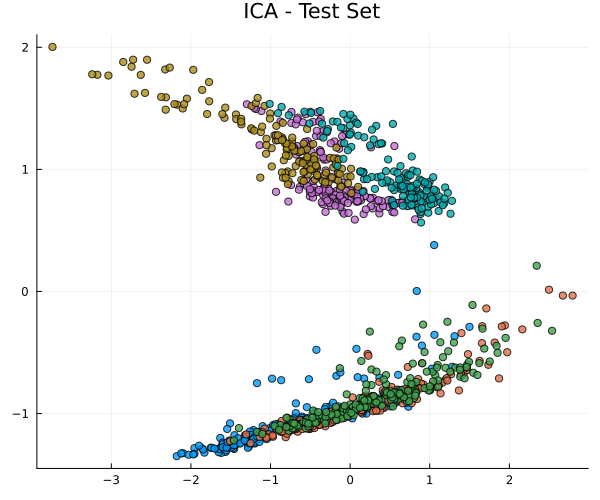

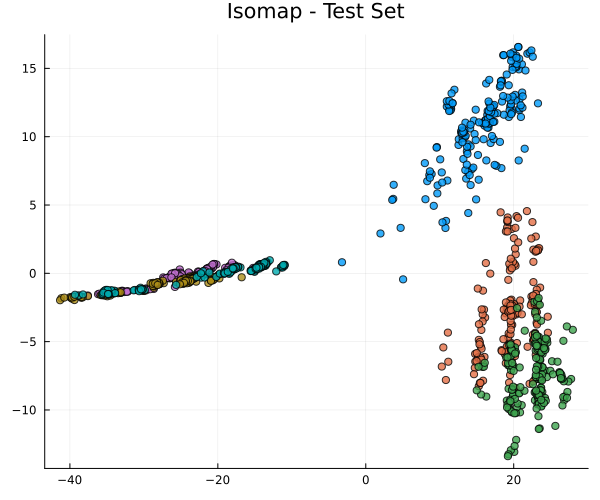

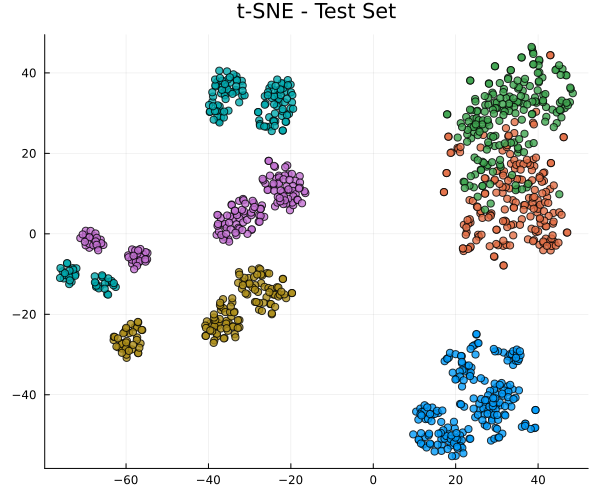

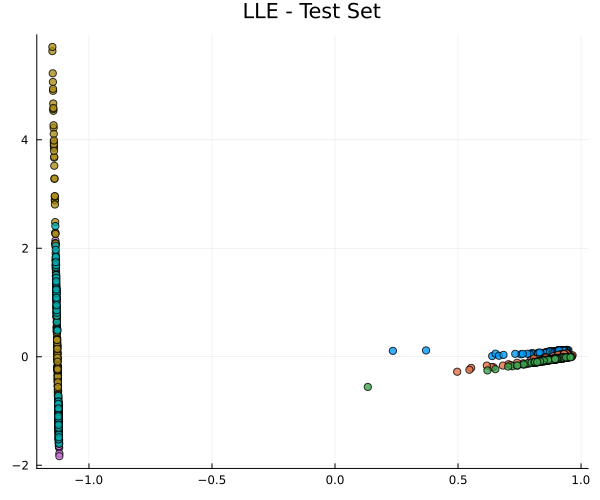

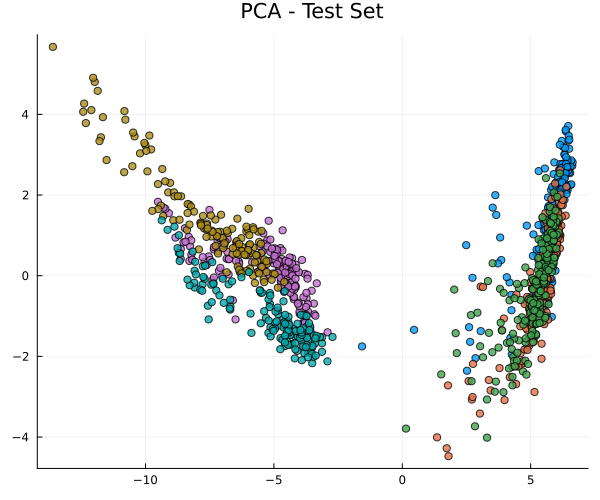

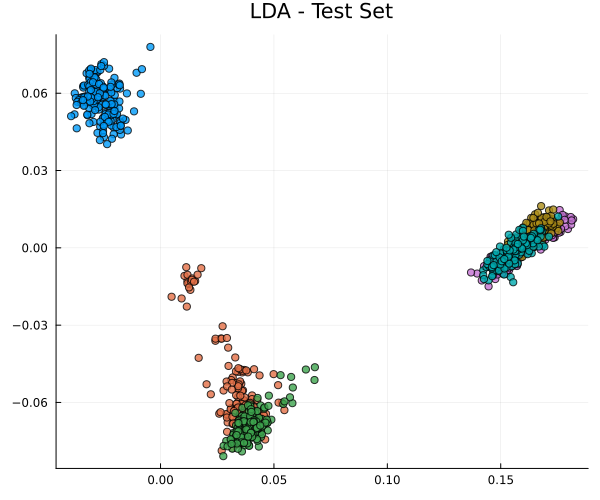

In [25]:
gr()

function plot_and_save(;x, y, targets, title_str)

    target_strings = string.(vec(targets))
    
    # Gráfico principal sin leyenda
    p = Plots.scatter(x, y, 
                group=target_strings, 
                title="$title_str - Test Set", 
                legend=false, 
                markersize=4, 
                alpha=0.8,
                size=(600,500))

    Plots.display(p)

    filename = lowercase(replace(title_str, " " => "_")) * "_test.png"
    fullpath = joinpath("visualizacion", filename)
    Plots.savefig(p, fullpath)

end

reducers = Dict(
    "PCA" => PCA(maxoutdim=2),
    "ICA" => ICA(outdim=2),
    "LDA" => LDA(outdim=2, regcoef=1e-2),
    "Isomap" => Isomap(d = 2),
    "t-SNE" => TSNE(d = 2),
    "LLE" => LLE(k = 50, d = 2),
)


y_train = categorical(findfirst.(x -> x==1, eachrow(trainTargets)))

trainData = Float64.(trainData)
testData = Float64.(testData)

for (name, model) in reducers
    if MLJModelInterface.is_supervised(model)
        out, _, _ = fit(model, 0, trainData, y_train)
    else
        out, _, _ = fit(model, 0, trainData)
    end
    transformed = transform(model, out, testData) 

    mat = (transformed isa AbstractMatrix) ? transformed : MLJModelInterface.matrix(transformed)

    plot_and_save(x =vec(mat[:, 1]), y = vec(mat[:, 2]), targets = testLabels, title_str = name)
end

## 6. Significación de variables

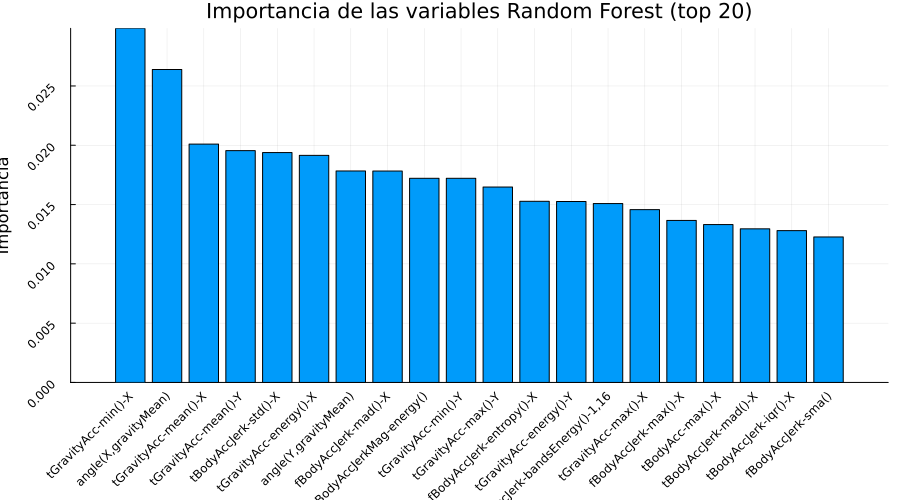

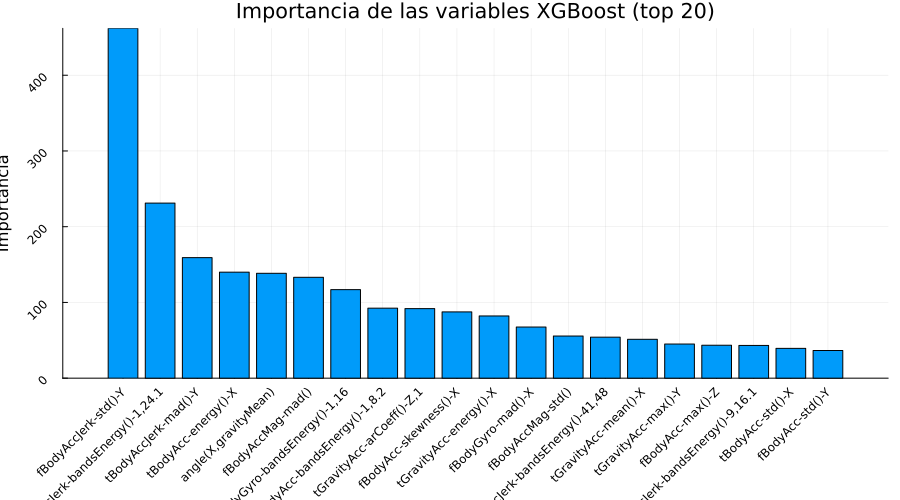

In [18]:
function plot_feature_importance(model, data, targets, name)
    rf_mach = machine(model, data, y_train, scitype_check_level=0)
    fit!(rf_mach, verbosity=0)


    rf_importances = feature_importances(rf_mach)  # Vector con una importancia por columna

    # Asociar cada importancia con el nombre de la variable
    feature_names = names(data)

    rf_imp_df = DataFrame(
        feature = [string(name) for (name, value) in rf_importances],
        importance = [value for (name, value) in rf_importances],
    )

    # Ordenar de mayor a menor importancia
    sort!(rf_imp_df, :importance, rev=true)

    # (Opcional) Quedarse con las 20 variables más importantes para visualizar
    topK = 20
    rf_imp_top = rf_imp_df[1:min(topK, nrow(rf_imp_df)), :]

    # Gráfico de barras ordenado (IMPORTANTE PARA LA RÚBRICA)
    Plots.display(Plots.bar(
        rf_imp_top.feature,
        rf_imp_top.importance,
        legend=false,
        xticks=:all, # si hay muchos nombres, ocultas etiquetas del eje x y las comentas en la memoria
        xlabel="Variables",
        ylabel="Importancia",
        title="Importancia de las variables $name (top $(topK))",
        size=(900, 500),
        rotation=45,
    ))

end


# Modelo con los hiperparámetros que pide el enunciado
rf_model = RandomForestClassifier(n_trees = 500, max_depth = 10)
xgBoost = XGBoostClassifier() 
y_train = categorical(findfirst.(x -> x==1, eachrow(trainTargets)))
# Entrenamos el modelo (usa tus propios Xtrain_df, ytrain)
data = dataset[trainIndices,:]

plot_feature_importance(rf_model, data, y_train, "Random Forest")
plot_feature_importance(xgBoost, data, y_train, "XGBoost")